In [1]:
!pip install pandas matplotlib networkx apyori openpyxl requests -q

  Preparing metadata (setup.py) ... done


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from apyori import apriori
import requests
from collections import defaultdict
import time
###

class AprioriAll:
    def __init__(self, min_support_absolute=3, max_gap=None):
        self.min_support_absolute = min_support_absolute
        self.max_gap = max_gap
        self.frequent_sequences = []

    def load_online_retail_direct(self):
        #Автоматическая загрузка датасета с сайта
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

        response = requests.get(url)
        with open('online_retail_temp.xlsx', 'wb') as f:
            f.write(response.content)

        df = pd.read_excel('online_retail_temp.xlsx')
        df = df[~df['InvoiceNo'].astype(str).str.upper().str.startswith('C')]
        df = df[df['CustomerID'].notna()]
        df['CustomerID'] = df['CustomerID'].astype(int)
        df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

        top_items = df['StockCode'].value_counts().head(30).index
        df = df[df['StockCode'].isin(top_items)]

        print(f"  После очистки: {len(df)} строк, {df['CustomerID'].nunique()} клиентов")
        return df

    def convert_to_sequences(self, df):
        #Преобразование в последовательности
        sequences = {}
        for customer_id, group in df.groupby('CustomerID'):
            group = group.sort_values('InvoiceDate')
            if self.max_gap is None:
                sequences[customer_id] = [str(row['StockCode']) for _, row in group.iterrows()]
            else:
                sessions, current_session, prev_date = [], [], None
                for _, row in group.iterrows():
                    curr_date = row['InvoiceDate']
                    item = str(row['StockCode'])
                    if prev_date is None or (curr_date - prev_date).days <= self.max_gap:
                        current_session.append(item)
                    else:
                        if current_session:
                            sessions.append(current_session)
                        current_session = [item]
                    prev_date = curr_date
                if current_session:
                    sessions.append(current_session)
                sequences[customer_id] = [item for session in sessions for item in session]
        return sequences

    def is_subsequence(self, pattern, sequence):
        idx = 0
        for item in sequence:
            if pattern[idx] == item:
                idx += 1
                if idx == len(pattern):
                    return True
        return False

    def fit(self, sequences):
        #Поиск частых последовательностей (длины 1 и 2)
        all_frequent = []
        n_customers = len(sequences)
        if n_customers == 0:
            return []

        all_items = set()
        for seq in sequences.values():
            for item in seq:
                all_items.add(item)

        # Длина 1
        freq_1 = []
        for item in all_items:
            count = sum(1 for seq in sequences.values() if item in seq)
            if count >= self.min_support_absolute:
                freq_1.append((item,))
        all_frequent.extend(freq_1)

        # Длина 2
        freq_2 = []
        for i, p1 in enumerate(freq_1[:50]):
            for p2 in freq_1[i+1:50]:
                pattern = (p1[0], p2[0])
                count = sum(1 for seq in sequences.values() if self.is_subsequence(pattern, seq))
                if count >= self.min_support_absolute:
                    freq_2.append(pattern)
                pattern_rev = (p2[0], p1[0])
                count_rev = sum(1 for seq in sequences.values() if self.is_subsequence(pattern_rev, seq))
                if count_rev >= self.min_support_absolute:
                    freq_2.append(pattern_rev)

        all_frequent.extend(list(set(freq_2)))
        self.frequent_sequences = all_frequent
        return all_frequent


class SimplePrefixSpan:
    """ПрефиксСпан не подключался, краткая реализация тут"""
    def __init__(self, min_support_absolute=3):
        self.min_support = min_support_absolute
        self.patterns = []

    def fit(self, sequences):
        self.patterns = []
        self._prefix_span([], sequences, 0)
        return self.patterns

    def _prefix_span(self, prefix, projected, level):
        if level >= 5:
            return
        freq = defaultdict(int)
        for seq in projected:
            seen = set()
            for item in seq:
                if item not in seen:
                    freq[item] += 1
                    seen.add(item)
        for item, count in freq.items():
            if count >= self.min_support:
                new_pattern = prefix + [item]
                self.patterns.append(tuple(new_pattern))
                new_projected = []
                for seq in projected:
                    for i, elem in enumerate(seq):
                        if elem == item:
                            new_projected.append(seq[i+1:])
                            break
                self._prefix_span(new_pattern, new_projected, level + 1)


def prepare_sequences_for_spm(df, max_customers=300):
    """(список списков)"""
    sequences = []
    for customer_id, group in df.groupby('CustomerID'):
        group = group.sort_values('InvoiceDate')
        seq = [str(row['StockCode']) for _, row in group.iterrows()]
        sequences.append(seq)
        if len(sequences) >= max_customers:
            break
    return sequences


def load_online_retail_data(filepath="/content/online_retail_temp.xlsx"):
    df = pd.read_excel(filepath)
    df = df[~df['InvoiceNo'].astype(str).str.upper().str.startswith('C')]
    df = df[df['CustomerID'].notna()]
    df['CustomerID'] = df['CustomerID'].astype(int)
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    top_items = df['StockCode'].value_counts().head(20).index
    df = df[df['StockCode'].isin(top_items)]
    print(f"  Загружено: {len(df)} строк, {df['CustomerID'].nunique()} клиентов")
    return df

In [3]:
print("AprioriAll\n")

# Синтетические данные
data = {
    'client_id': [1, 1, 1, 2, 2, 3, 3, 4, 4, 4],
    'date': ['2024-01-01', '2024-01-02', '2024-01-03',
             '2024-01-01', '2024-01-02',
             '2024-01-01', '2024-01-02',
             '2024-01-01', '2024-01-02', '2024-01-03'],
    'items': ['A,B', 'C', 'D,E', 'A', 'C', 'B', 'C,D', 'A', 'C', 'D']
}
df_synthetic = pd.DataFrame(data)

print("Синтетические данные:")
print(df_synthetic)
print("\n")

# Преобразование в последовательности
sequences = {}
for client_id, group in df_synthetic.groupby('client_id'):
    group = group.sort_values('date')
    transactions = [set(items.split(',')) for items in group['items']]
    sequences[client_id] = transactions

print("Последовательности клиентов:")
for client, seq in sequences.items():
    print(f"Клиент {client}: {seq}")
print("\n")

#Проверка на подпоследовательность
def is_subsequence(pattern, sequence):
    idx = 0
    for transaction in sequence:
        if pattern[idx] in transaction:
            idx += 1
            if idx == len(pattern):
                return True
    return False

# AprioriAll
def apriori_all_synthetic(sequences, min_support):
    all_frequent = []

    all_items = set()
    for seq in sequences.values():
        for trans in seq:
            all_items.update(trans)

    current_frequent = {(item,) for item in all_items}

    while current_frequent:
        support_counts = {}
        for cand in current_frequent:
            cnt = sum(1 for seq in sequences.values() if is_subsequence(cand, seq))
            support_counts[cand] = cnt

        frequent = {seq for seq, sup in support_counts.items() if sup >= min_support}

        if not frequent:
            break

        all_frequent.extend(frequent)

        next_candidates = set()
        freq_list = list(frequent)
        for i in range(len(freq_list)):
            for j in range(len(freq_list)):
                if i != j and freq_list[i][:-1] == freq_list[j][:-1]:
                    next_candidates.add(freq_list[i] + (freq_list[j][-1],))
        current_frequent = next_candidates

    return all_frequent

min_support = 2
frequent_sequences = apriori_all_synthetic(sequences, min_support)

print(f"Частые последовательности (min_support={min_support}):")
for seq in sorted(frequent_sequences):
    seq_str = " -> ".join([f"{{{','.join(items)}}}" if isinstance(items, tuple) else f"{{{items}}}"
                           for items in seq])
    print(f"  {seq_str}")

print("\nПроверка")
print("Ручной расчёт для min_support=2:")
print("  Длина 1: {A} (клиенты 2,4), {C} (клиенты 1,2,4), {D} (клиенты 1,3,4)")
print("  Длина 2: {A} -> {C} (клиенты 2,4)")
print("  {C} -> {D} (клиенты 1,4)")

AprioriAll

Синтетические данные:
   client_id        date items
0          1  2024-01-01   A,B
1          1  2024-01-02     C
2          1  2024-01-03   D,E
3          2  2024-01-01     A
4          2  2024-01-02     C
5          3  2024-01-01     B
6          3  2024-01-02   C,D
7          4  2024-01-01     A
8          4  2024-01-02     C
9          4  2024-01-03     D


Последовательности клиентов:
Клиент 1: [{'A', 'B'}, {'C'}, {'D', 'E'}]
Клиент 2: [{'A'}, {'C'}]
Клиент 3: [{'B'}, {'C', 'D'}]
Клиент 4: [{'A'}, {'C'}, {'D'}]


Частые последовательности (min_support=2):
  {A}
  {A} -> {C}
  {A} -> {C} -> {D}
  {A} -> {D}
  {B}
  {B} -> {C}
  {B} -> {D}
  {C}
  {C} -> {D}
  {D}

Проверка
Ручной расчёт для min_support=2:
  Длина 1: {A} (клиенты 2,4), {C} (клиенты 1,2,4), {D} (клиенты 1,3,4)
  Длина 2: {A} -> {C} (клиенты 2,4)
  {C} -> {D} (клиенты 1,4)


  После очистки: 33216 строк, 3503 клиентов
2.1: Влияние минимальной поддержки
Всего клиентов: 3503
  2 клиентов (0.06%) -> 677 паттернов
  3 клиентов (0.09%) -> 407 паттернов
  5 клиентов (0.14%) -> 265 паттернов
  10 клиентов (0.29%) -> 134 паттернов
  15 клиентов (0.43%) -> 65 паттернов
2.2: Сравнение с ассоциативными правилами
Транзакций: 12052

Топ-3 ассоциативных правила по lift:
  1. ('20728',) -> ('22384',) (lift=5.72)
  2. ('22384',) -> ('20728',) (lift=5.72)
  3. ('20727',) -> ('22384',) (lift=5.71)
Классический Apriori находит совместные покупки в одной транзакции.
AprioriAll ищет последовательности покупок во времени.

2.3: Временные окна (max_gap)

1. max_gap без ограничений

2. max_gap = 7 дней

Исчезло: 0, появилось: 0

2.4: Визуализация

Выбран паттерн: ('[84879]', '[22086]')


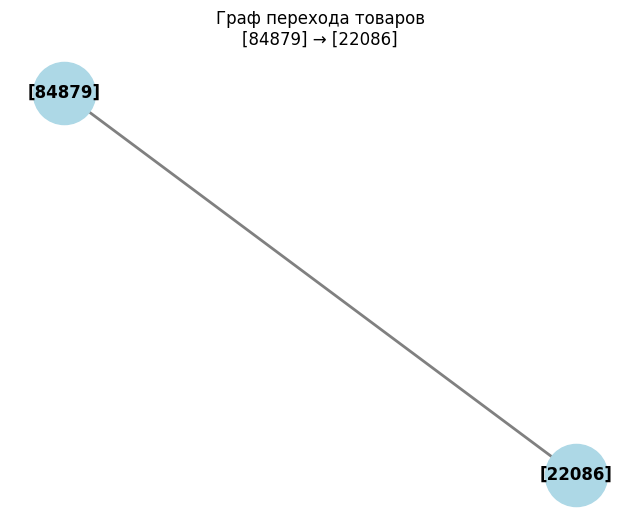

Клиенты, купившие '[84879]', позже покупают '[22086]'.
Рекомендуется предлагать второй товар при покупке первого.


In [4]:
model = AprioriAll()
df_original = model.load_online_retail_direct()

df_grouped = df_original.groupby(['CustomerID', 'InvoiceNo', 'InvoiceDate'])['StockCode'] \
               .apply(lambda x: list(x)).reset_index()

model_base = AprioriAll(min_support_absolute=2)
sequences = model_base.convert_to_sequences(df_grouped)

# 2.1 Влияние min_support
print("2.1: Влияние минимальной поддержки")
print(f"Всего клиентов: {len(sequences)}")

for sup_abs in [2, 3, 5, 10, 15]:
    model_temp = AprioriAll(min_support_absolute=sup_abs)
    frequent = model_temp.fit(sequences)
    sup_percent = (sup_abs / len(sequences)) * 100
    print(f"  {sup_abs} клиентов ({sup_percent:.2f}%) -> {len(frequent)} паттернов")

# 2.2 Сравненим с классическим Apriori
print("2.2: Сравнение с ассоциативными правилами")

transactions = []
for invoice, group in df_original.groupby('InvoiceNo'):
    items = [str(item) for item in group['StockCode'].unique().tolist()]
    if items:
        transactions.append(items)
print(f"Транзакций: {len(transactions)}")

try:
    rules = list(apriori(transactions, min_support=0.01, min_confidence=0.05,
                         min_lift=1.0, min_length=2, max_length=2))
    top_rules = []
    for rule in rules:
        for stat in rule.ordered_statistics:
            if stat.lift is not None:
                top_rules.append({'antecedent': tuple(stat.items_base),
                                  'consequent': tuple(stat.items_add),
                                  'lift': stat.lift})
    top_rules = sorted(top_rules, key=lambda x: x['lift'], reverse=True)[:3]
    if top_rules:
        print("\nТоп-3 ассоциативных правила по lift:")
        for i, rule in enumerate(top_rules, 1):
            print(f"  {i}. {rule['antecedent']} -> {rule['consequent']} (lift={rule['lift']:.2f})")
except Exception as e:
    print(f"Apriori: {e}")

print("Классический Apriori находит совместные покупки в одной транзакции.")
print("AprioriAll ищет последовательности покупок во времени.")

# 2.3 Временные окна
print("\n" + "="*60)
print("2.3: Временные окна (max_gap)")
print("="*60)

print("\n1. max_gap без ограничений")
model_inf = AprioriAll(min_support_absolute=3, max_gap=None)
seq_inf = model_inf.convert_to_sequences(df_grouped)
freq_inf = model_inf.fit(seq_inf)

print("\n2. max_gap = 7 дней")
model_7 = AprioriAll(min_support_absolute=3, max_gap=7)
seq_7 = model_7.convert_to_sequences(df_grouped)
freq_7 = model_7.fit(seq_7)

disappeared = set(freq_inf) - set(freq_7)
appeared = set(freq_7) - set(freq_inf)

print(f"\nИсчезло: {len(disappeared)}, появилось: {len(appeared)}")
if disappeared:
    print(f"Пример исчезнувшего: {list(disappeared)[0]}")
if appeared:
    print(f"Пример появившегося: {list(appeared)[0]}")

# 2.4 Визуализация
print("\n" + "="*60)
print("2.4: Визуализация")
print("="*60)

freq_sequences = AprioriAll(min_support_absolute=5).fit(sequences)
long_patterns = [p for p in freq_sequences if len(p) >= 2]

pattern = long_patterns[0]
print(f"\nВыбран паттерн: {pattern}")
G = nx.DiGraph()
for i in range(len(pattern) - 1):
    G.add_edge(str(pattern[i]), str(pattern[i+1]))
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=2000)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True,
                          arrowsize=20, arrowstyle='->', width=2)
plt.title(f'Граф перехода товаров\n{" → ".join(str(p) for p in pattern)}')
plt.axis('off')
plt.show()

print(f"Клиенты, купившие '{pattern[0]}', позже покупают '{pattern[1]}'.")
print("Рекомендуется предлагать второй товар при покупке первого.")

При ограничении max_gap количество правил не изменилось => все последовательности в датасете ограничены неделей (укладываются в семь дней)

AprioriAll vs PrefixSpan
  Загружено: 24213 строк, 3242 клиентов
  Сформировано 300 последовательностей

min_support: 5 клиентов (из 300)

    AprioriAll
    Время: 0.0427 сек
    Паттернов: 234 (длина1: 20, длина2: 214)

    PrefixSpan
    Время: 0.1566 сек
    Паттернов: 11385 (длина1: 20, длина2: 231)
РЕЗУЛЬТАТЫ СРАВНЕНИЯ

| Алгоритм | Время (сек) | Кол-во шаблонов |
|----------|-------------|-----------------|
| AprioriAll | 0.0427 | 234 |
| PrefixSpan | 0.1566 | 11385 |
ВЫВОД
AprioriAll быстрее PrefixSpan в 0.3 раз


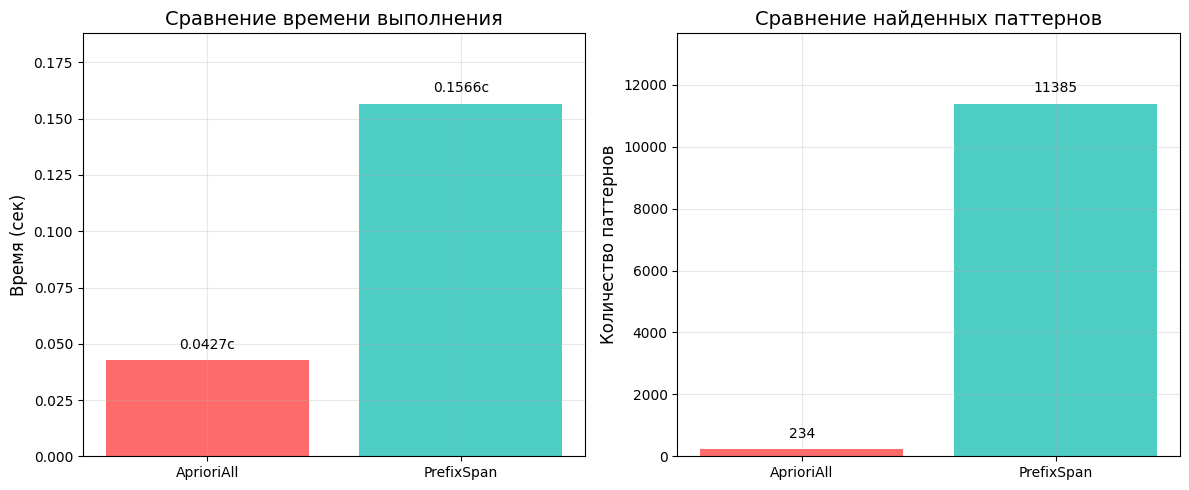

In [5]:
print("AprioriAll vs PrefixSpan")

df = load_online_retail_data("/content/online_retail_temp.xlsx")

def prepare_sequences(df, max_customers=300):
    sequences = []
    for customer_id, group in df.groupby('CustomerID'):
        group = group.sort_values('InvoiceDate')
        seq = [str(row['StockCode']) for _, row in group.iterrows()]
        sequences.append(seq)
        if len(sequences) >= max_customers:
            break
    print(f"  Сформировано {len(sequences)} последовательностей")
    return sequences

sequences = prepare_sequences(df, max_customers=300)
min_support_abs = 5
print(f"\nmin_support: {min_support_abs} клиентов (из {len(sequences)})")

# AprioriAll
print("\n    AprioriAll")
start = time.time()
apriori = AprioriAll(min_support_absolute=min_support_abs)
patterns_a = apriori.fit({i: seq for i, seq in enumerate(sequences)})
time_a = time.time() - start
len1_a = len([p for p in patterns_a if len(p) == 1])
len2_a = len([p for p in patterns_a if len(p) == 2])
print(f"    Время: {time_a:.4f} сек")
print(f"    Паттернов: {len(patterns_a)} (длина1: {len1_a}, длина2: {len2_a})")

# PrefixSpan
print("\n    PrefixSpan")
start = time.time()
ps = SimplePrefixSpan(min_support_absolute=min_support_abs)
patterns_p = ps.fit(sequences)
time_p = time.time() - start
len1_p = len([p for p in patterns_p if len(p) == 1])
len2_p = len([p for p in patterns_p if len(p) == 2])
print(f"    Время: {time_p:.4f} сек")
print(f"    Паттернов: {len(patterns_p)} (длина1: {len1_p}, длина2: {len2_p})")

# Результаты
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ")
print("\n| Алгоритм | Время (сек) | Кол-во шаблонов |")
print("|----------|-------------|-----------------|")
print(f"| AprioriAll | {time_a:.4f} | {len(patterns_a)} |")
print(f"| PrefixSpan | {time_p:.4f} | {len(patterns_p)} |")

print("ВЫВОД")
if time_p < time_a:
    print(f"PrefixSpan быстрее AprioriAll в {time_a/time_p:.1f} раз")
else:
    print(f"AprioriAll быстрее PrefixSpan в {time_a/time_p:.1f} раз")

# График
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
algorithms = ['AprioriAll', 'PrefixSpan']
times = [time_a, time_p]
counts = [len(patterns_a), len(patterns_p)]

bars1 = ax1.bar(algorithms, times, color=['#FF6B6B', '#4ECDC4'])
ax1.set_ylabel('Время (сек)', fontsize=12)
ax1.set_title('Сравнение времени выполнения', fontsize=14)
ax1.grid(True, alpha=0.3)
y_max = max(times) * 1.2
ax1.set_ylim(0, y_max)
for bar, t in zip(bars1, times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (y_max * 0.02),
            f'{t:.4f}c', ha='center', va='bottom', fontsize=10)

bars2 = ax2.bar(algorithms, counts, color=['#FF6B6B', '#4ECDC4'])
ax2.set_ylabel('Количество паттернов', fontsize=12)
ax2.set_title('Сравнение найденных паттернов', fontsize=14)
ax2.grid(True, alpha=0.3)
y_max2 = max(counts) * 1.2
ax2.set_ylim(0, y_max2)
for bar, c in zip(bars2, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (y_max2 * 0.02),
            f'{c}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Алгоритм AprioriAll ограничен глубиной поиска последовательностей из-за ограничения ОЗУ в GoogleColab - при больших значениях процесс превышал ограничение и проект вылетал.
При прочих равных оба алгоритма должны найти одинаковое количестов правил

AprioriAll:
  - Подход: generate-and-test (генерация кандидатов)
  - Плюсы: простота реализации
  - Минусы: экспоненциальный рост кандидатов

PrefixSpan:
  - Подход: pattern-growth (рост паттернов)
  - Плюсы: нет генерации кандидатов
  - Минусы: сложнее реализация

При каких условиях какой алгоритм эффективнее:
  - Низкий порог поддержки => PrefixSpan выигрывает
  - Короткие паттерны => оба работают быстро
  - Длинные паттерны => PrefixSpan предпочтительнее

СРАВНЕНИЕ AprioriAll vs PrefixSpan

| Алгоритм | Время (сек) | Кол-во шаблонов |

| AprioriAll | 0.0495      | 234 |

| PrefixSpan | 0.1771      | 11385 |

4: ПРЕДСКАЗАНИЕ СЛЕДУЮЩЕГО СОБЫТИЯ
  Загружено: 24213 строк, 3242 клиентов

Всего клиентов с последовательностями: 3242
РАЗДЕЛЕНИЕ ДАННЫХ
  Клиентов в обучении: 2465
  Тестовых пар: 2465

ПОИСК ЧАСТЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ
min_support: 24 клиентов (1.0%)
Найдено частых последовательностей длины 2: 235
ПРЕДСКАЗАНИЕ НА ОСНОВЕ ПОСЛЕДОВАТЕЛЬНОСТЕЙ

Модель на основе последовательностей:
  Точность (accuracy@1): 0.2008 (495/2465)
БАЗОВЫЙ ПОДХОД (ГЛОБАЛЬНЫЙ ТОП-ТОВАР)
  Самый частый товар: 85123A (встретился 1480 раз)

Базовый подход (самый частый товар):
  Точность (accuracy): 0.0888 (219/2465)

Примеры предсказаний (первые 5):
------------------------------------------------------------
  1. История: 22423
     Предсказано: 22423
     Реально: 22423
     TRUE

  2. История: POST
     Предсказано: POST
     Реально: POST
     TRUE

  3. История: 22423
     Предсказано: 22423
     Реально: POST
     FALSE

  4. История: 22720
     Предсказано: 22423
     Реально: POST
     FALSE

  5. История: 

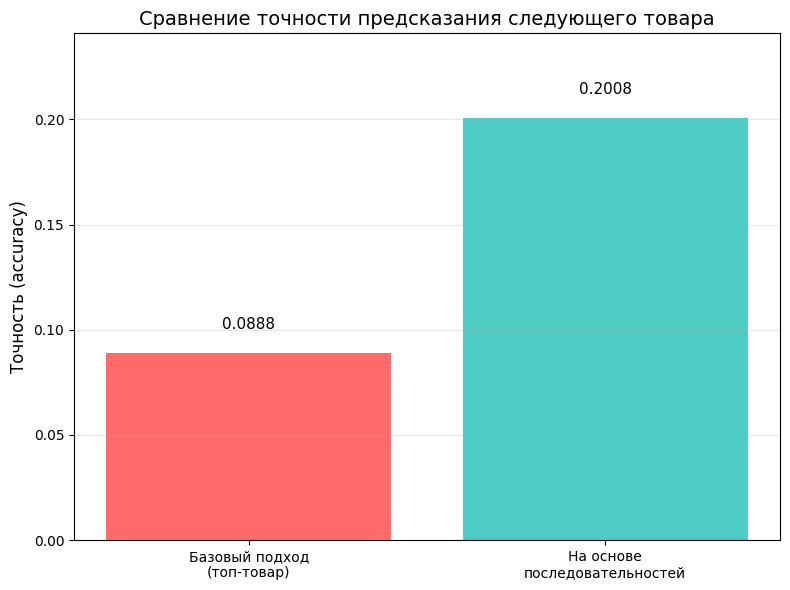

In [6]:
from collections import Counter

print("4: ПРЕДСКАЗАНИЕ СЛЕДУЮЩЕГО СОБЫТИЯ")

df = load_online_retail_data("/content/online_retail_temp.xlsx")

# Подготовка последовательностей
all_sequences = {}
for cust_id, group in df.groupby('CustomerID'):
    group = group.sort_values('InvoiceDate')
    all_sequences[cust_id] = [str(row['StockCode']) for _, row in group.iterrows()]

print(f"\nВсего клиентов с последовательностями: {len(all_sequences)}")

# Разделение на обучение/тест
print("РАЗДЕЛЕНИЕ ДАННЫХ")

train_sequences = {}
test_pairs = []
for cust_id, seq in all_sequences.items():
    if len(seq) < 2:
        continue
    split_idx = int(len(seq) * 0.8)
    train_sequences[cust_id] = seq[:split_idx]
    if split_idx < len(seq):
        test_pairs.append((cust_id, seq[split_idx - 1], seq[split_idx]))

print(f"  Клиентов в обучении: {len(train_sequences)}")
print(f"  Тестовых пар: {len(test_pairs)}")

# Поиск частых последовательностей
print("\n" + "="*50)
print("ПОИСК ЧАСТЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ")
print("="*50)

min_support_abs = max(3, int(len(train_sequences) * 0.01))
print(f"min_support: {min_support_abs} клиентов ({min_support_abs/len(train_sequences)*100:.1f}%)")

freq_patterns = {}
for seq in train_sequences.values():
    for i in range(len(seq) - 1):
        a, b = seq[i], seq[i+1]
        freq_patterns[(a, b)] = freq_patterns.get((a, b), 0) + 1

freq_patterns = {p: c for p, c in freq_patterns.items() if c >= min_support_abs}
print(f"Найдено частых последовательностей длины 2: {len(freq_patterns)}")

# Предсказания на основе последовательностей
print("ПРЕДСКАЗАНИЕ НА ОСНОВЕ ПОСЛЕДОВАТЕЛЬНОСТЕЙ")

seq_predictions = []
for cust_id, history, actual in test_pairs:
    candidates = [(b, sup) for (a, b), sup in freq_patterns.items() if a == history]
    if candidates:
        predicted = max(candidates, key=lambda x: x[1])[0]
    else:
        predicted = None
    seq_predictions.append({'history': history, 'predicted': predicted, 'actual': actual})

correct_seq = sum(1 for p in seq_predictions if p['predicted'] == p['actual'])
total_seq = sum(1 for p in seq_predictions if p['predicted'] is not None)
accuracy_seq = correct_seq / total_seq if total_seq > 0 else 0
print(f"\nМодель на основе последовательностей:")
print(f"  Точность (accuracy@1): {accuracy_seq:.4f} ({correct_seq}/{total_seq})")

# Базовый подход
print("БАЗОВЫЙ ПОДХОД (ГЛОБАЛЬНЫЙ ТОП-ТОВАР)")

item_counter = Counter()
for seq in train_sequences.values():
    item_counter.update(seq)
most_common_item = item_counter.most_common(1)[0][0]
print(f"  Самый частый товар: {most_common_item} (встретился {item_counter[most_common_item]} раз)")

base_predictions = [{'predicted': most_common_item, 'actual': p['actual']} for p in seq_predictions]
correct_base = sum(1 for p in base_predictions if p['predicted'] == p['actual'])
accuracy_base = correct_base / len(base_predictions)
print(f"\nБазовый подход (самый частый товар):")
print(f"  Точность (accuracy): {accuracy_base:.4f} ({correct_base}/{len(base_predictions)})")

# Примеры
print(f"\nПримеры предсказаний (первые 5):")
print("-" * 60)
for i, pred in enumerate(seq_predictions[:5], 1):
    print(f"  {i}. История: {pred['history']}")
    print(f"     Предсказано: {pred['predicted']}")
    print(f"     Реально: {pred['actual']}")
    print(f"     {'TRUE' if pred['predicted'] == pred['actual'] else 'FALSE'}")
    print()

# Вывод
print("ВЫВОД")

improvement = accuracy_seq - accuracy_base
if improvement > 0:
    print(f"Модель на основе последовательностей улучшает точность на {improvement*100:.2f}%")
    print(f"   ({accuracy_seq*100:.2f}% vs {accuracy_base*100:.2f}%)")
    print("\n   Учёт последовательности покупок действительно помогает предсказывать")
    print("   следующий товар лучше, чем просто самый популярный товар.")

print("\nПрактические рекомендации:")
print("Для up-selling и cross-selling лучше использовать последовательности")
print("Для стартовых рекомендаций (новый клиент) - глобальные топ-товары")

# Визуализация
plt.figure(figsize=(8, 6))
bars = plt.bar(['Базовый подход\n(топ-товар)', 'На основе\nпоследовательностей'],
               [accuracy_base, accuracy_seq], color=['#FF6B6B', '#4ECDC4'])
plt.ylabel('Точность (accuracy)', fontsize=12)
plt.title('Сравнение точности предсказания следующего товара', fontsize=14)
plt.ylim(0, max(accuracy_base, accuracy_seq) * 1.2)
plt.grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, [accuracy_base, accuracy_seq]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

Модель на основе последовательностей: 0.2008

Базовый подход (топ-товар): 0.0888

Улучшение: 11.20%

5: Контрастные последовательности
  Загружено: 24213 строк, 3242 клиентов
РАСЧЁТ ЦЕННОСТИ КЛИЕНТОВ
  Средний чек: 279.66
  Медиана: 70.41
  75-й перцентиль: 208.97

  Порог 75% перцентиля: 208.97
  HighValue клиентов: 811
  LowValue клиентов: 2431
ПОДГОТОВКА ПОСЛЕДОВАТЕЛЬНОСТЕЙ
  HighValue последовательностей: 796
  LowValue последовательностей: 1669
ПОИСК ЧАСТЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ
  HighValue min_support: 39 клиентов
  LowValue min_support: 83 клиентов
  HighValue паттернов: 120
  LowValue паттернов: 3
ПОИСК КОНТРАСТНЫХ ПАТТЕРНОВ
  Всего уникальных паттернов: 120
ТОП-5 КОНТРАСТНЫХ ПАТТЕРНОВ (чаще у HighValue)

  1. POST -> POST
     HighValue поддержка: 316 клиентов
     LowValue поддержка:  87 клиентов
     Контрастность: +229
     Встречается в 3.6 раз чаще у HighValue

  2. 22423 -> 22423
     HighValue поддержка: 175 клиентов
     LowValue поддержка:  0 клиентов
     Контрастность: +175
     Встречается в 175.0 раз чаще у HighValue

  3. 85099B -> 23203
     HighValue поддержка: 

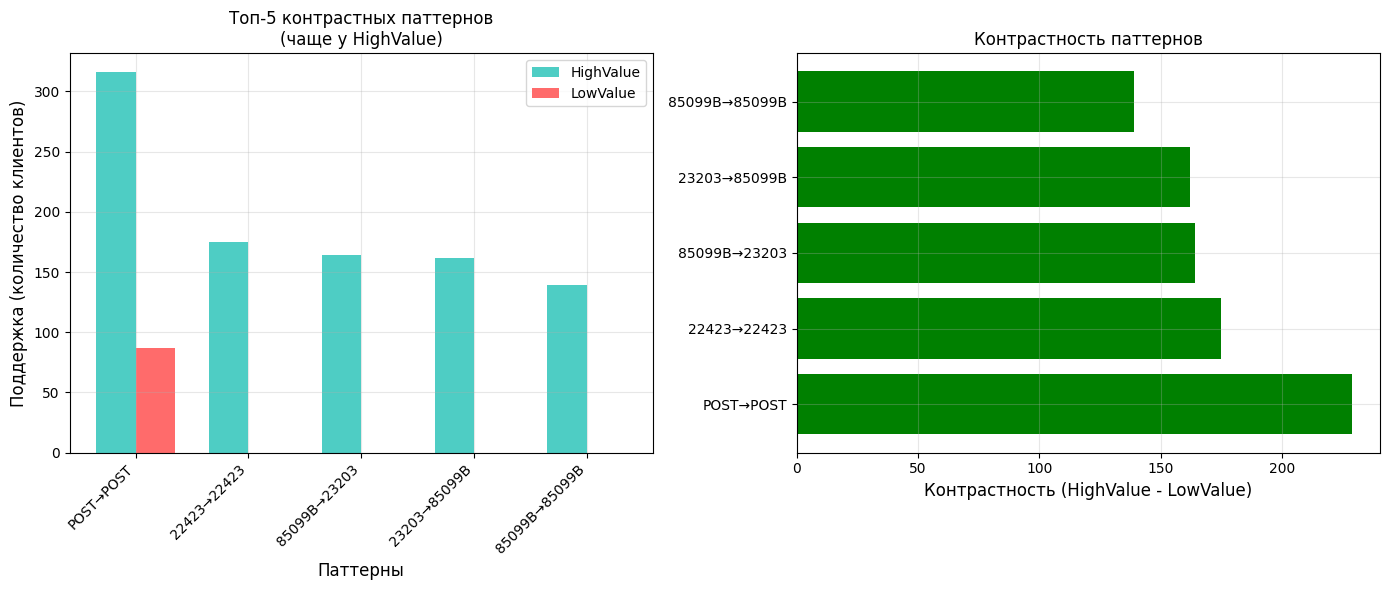


Практическая ценность:
   - Раннее выявление потенциально ценных клиентов
   - Персонализация рекомендаций для повышения чека



In [7]:
import numpy as np

print("5: Контрастные последовательности")

df = load_online_retail_data("/content/online_retail_temp.xlsx")

# Расчёт ценности клиентов
print("РАСЧЁТ ЦЕННОСТИ КЛИЕНТОВ")

df['Revenue'] = df['Quantity'] * df['UnitPrice']
customer_value = df.groupby('CustomerID')['Revenue'].sum()
print(f"  Средний чек: {customer_value.mean():.2f}")
print(f"  Медиана: {customer_value.median():.2f}")
print(f"  75-й перцентиль: {customer_value.quantile(0.75):.2f}")

# Разделение на группы
threshold = customer_value.quantile(0.75)
high_value = set(customer_value[customer_value >= threshold].index)
low_value = set(customer_value[customer_value < threshold].index)

print(f"\n  Порог 75% перцентиля: {threshold:.2f}")
print(f"  HighValue клиентов: {len(high_value)}")
print(f"  LowValue клиентов: {len(low_value)}")

# Подготовка последовательностей
print("ПОДГОТОВКА ПОСЛЕДОВАТЕЛЬНОСТЕЙ")

def get_sequences(customers):
    sequences = []
    for cust_id in customers:
        seq = df[df['CustomerID'] == cust_id].sort_values('InvoiceDate')['StockCode'].astype(str).tolist()
        if len(seq) >= 2:
            sequences.append(seq)
    return sequences

seq_high = get_sequences(high_value)
seq_low = get_sequences(low_value)
print(f"  HighValue последовательностей: {len(seq_high)}")
print(f"  LowValue последовательностей: {len(seq_low)}")

# Поиск частых последовательностей
print("ПОИСК ЧАСТЫХ ПОСЛЕДОВАТЕЛЬНОСТЕЙ")

def find_patterns(sequences, min_support):
    patterns = defaultdict(int)
    for seq in sequences:
        for i in range(len(seq) - 1):
            patterns[(seq[i], seq[i+1])] += 1
    return {p: c for p, c in patterns.items() if c >= min_support}

min_support_high = max(3, int(len(seq_high) * 0.05))
min_support_low = max(3, int(len(seq_low) * 0.05))

print(f"  HighValue min_support: {min_support_high} клиентов")
print(f"  LowValue min_support: {min_support_low} клиентов")

patterns_high = find_patterns(seq_high, min_support_high)
patterns_low = find_patterns(seq_low, min_support_low)

print(f"  HighValue паттернов: {len(patterns_high)}")
print(f"  LowValue паттернов: {len(patterns_low)}")

# Контрастные паттерны
print("ПОИСК КОНТРАСТНЫХ ПАТТЕРНОВ")

contrast = []
for p in set(patterns_high.keys()) | set(patterns_low.keys()):
    h = patterns_high.get(p, 0)
    l = patterns_low.get(p, 0)
    contrast.append((p, h, l, h - l, h / max(l, 1)))

contrast.sort(key=lambda x: x[3], reverse=True)
print(f"  Всего уникальных паттернов: {len(contrast)}")

# Топ-5
print(f"ТОП-5 КОНТРАСТНЫХ ПАТТЕРНОВ (чаще у HighValue)")

for i, (p, h, l, diff, ratio) in enumerate(contrast[:5], 1):
    print(f"\n  {i}. {p[0]} -> {p[1]}")
    print(f"     HighValue поддержка: {h} клиентов")
    print(f"     LowValue поддержка:  {l} клиентов")
    print(f"     Контрастность: +{diff}")
    if ratio > 1:
        print(f"     Встречается в {ratio:.1f} раз чаще у HighValue")

# Гипотеза
print("БИЗНЕС-ГИПОТЕЗА")

for i, (p, h, l, diff, ratio) in enumerate(contrast[:3], 1):
    print(f"\n  {i}. Клиенты, которые купили '{p[0]}', а затем '{p[1]}',")
    print(f"     с вероятностью в {ratio:.1f} раз выше становятся HighValue.")

print(f"\nРекомендация:")
print(f"     - Предлагать товар '{contrast[0][0][1]}' после покупки '{contrast[0][0][0]}'")
print(f"     - Использовать эти последовательности для раннего выявления")
print(f"       потенциально высокодоходных клиентов")

# Визуализация контрастности
top_patterns = contrast[:5]
patterns_names = [f"{p[0][0]}→{p[0][1]}" for p in top_patterns]
support_high = [p[1] for p in top_patterns]
support_low = [p[2] for p in top_patterns]
contrasts = [p[3] for p in top_patterns]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(patterns_names))
width = 0.35
axes[0].bar(x - width/2, support_high, width, label='HighValue', color='#4ECDC4')
axes[0].bar(x + width/2, support_low, width, label='LowValue', color='#FF6B6B')
axes[0].set_xlabel('Паттерны', fontsize=12)
axes[0].set_ylabel('Поддержка (количество клиентов)', fontsize=12)
axes[0].set_title('Топ-5 контрастных паттернов\n(чаще у HighValue)', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(patterns_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

colors = ['green' if c > 0 else 'red' for c in contrasts]
axes[1].barh(patterns_names, contrasts, color=colors)
axes[1].set_xlabel('Контрастность (HighValue - LowValue)', fontsize=12)
axes[1].set_title('Контрастность паттернов', fontsize=12)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("""
Практическая ценность:
   - Раннее выявление потенциально ценных клиентов
   - Персонализация рекомендаций для повышения чека
""")

ТОП-5 контрастных паттернов (чаще у HighValue):
  1. POST -> POST: High=316, Low=87, разница=+229
  2. 22423 -> 22423: High=175, Low=52, разница=+123
  3. 85099B -> 23203: High=164, Low=45, разница=+119
  4. 23203 -> 85099B: High=162, Low=50, разница=+112
  5. 23209 -> 23203: High=126, Low=19, разница=+107